# LAB 02 — Context length (Bài 23)

Câu hỏi: **Context dài hơn có luôn tốt hơn không?** (Unigram / Bigram / Trigram trên cùng một corpus)

Dựa trên: perplexity (train / valid / test), số lượng n-gram, số lượng n-gram chưa từng thấy (unseen).
Chia dữ liệu 8 : 1 : 1, seed 42, giống các experiment trước.


In [ ]:
import copy
import gzip
import json
import math
import random
import re
import sys
from collections import Counter

import pandas as pd

SOS = "<s>"
EOS = "</s>"


def split_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    return [s.strip() for s in sentences if s.strip()]


def tokenize(sentence):
    return [sys.intern(t) for t in re.findall(r"[a-z\u00e0-\u1ef9\u0300-\u036f0-9]+", sentence.lower())]


def load_documents(path, text_field="text", limit=None):
    opener = gzip.open if path.endswith(".gz") else open
    docs = []
    with opener(path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            docs.append(json.loads(line)[text_field] if ".json" in path else line)
            if limit is not None and len(docs) >= limit:
                break
    return docs


def prepare_sentences(docs):
    """docs -> list cac cau, moi cau la list token."""
    sentences = []
    for doc in docs:
        for s in split_sentences(doc):
            tokens = tokenize(s)
            if tokens:
                sentences.append(tokens)
    return sentences

In [ ]:
import copy
import math
import random
from collections import Counter


def build_vocabulary(sentences, min_count=1):
    counts = Counter(w for s in sentences for w in s)
    vocab = {w for w, c in counts.items() if c >= min_count}
    vocab.add(EOS)
    return vocab


def pad_sentence(tokens, n):
    return [SOS] * (n - 1) + list(tokens) + [EOS]


def count_ngrams(sentences, n):
    counts = Counter()
    for tokens in sentences:
        padded = pad_sentence(tokens, n)
        for i in range(len(padded) - n + 1):
            counts[tuple(padded[i:i + n])] += 1
    return counts


def count_contexts(ngram_counts):
    contexts = Counter()
    for ngram, c in ngram_counts.items():
        contexts[ngram[:-1]] += c
    return contexts


class NGramLanguageModel:
    """smoothing: "none" (MLE), "laplace" (add-one) hoac "add_k" (cong k vao moi count)."""

    def __init__(self, n, smoothing="none", k=1.0):
        assert n in (1, 2, 3)
        assert smoothing in ("none", "laplace", "add_k")
        self.n = n
        self.smoothing = smoothing
        self.k = 1.0 if smoothing == "laplace" else k

    def fit(self, sentences, vocab=None):
        self.vocab = vocab if vocab is not None else build_vocabulary(sentences)
        self.ngram_counts = count_ngrams(sentences, self.n)
        self.context_counts = count_contexts(self.ngram_counts)
        return self

    def with_smoothing(self, smoothing, k=1.0):
        """Model moi dung chung count, chi doi smoothing."""
        other = copy.copy(self)
        other.smoothing = smoothing
        other.k = 1.0 if smoothing == "laplace" else k
        return other

    def _normalize_context(self, context):
        if self.n == 1:
            return ()
        ctx = list(context)[-(self.n - 1):]
        ctx = [SOS] * (self.n - 1 - len(ctx)) + ctx
        return tuple(ctx)

    def probability(self, context, word):
        ctx = self._normalize_context(context)
        count = self.ngram_counts.get(ctx + (word,), 0)
        ctx_count = self.context_counts.get(ctx, 0)
        if self.smoothing != "none":
            return (count + self.k) / (ctx_count + self.k * len(self.vocab))
        if ctx_count == 0:
            return 0.0
        return count / ctx_count

    def perplexity(self, sentences):
        """Tra ve (perplexity, ty le token co xac suat = 0). PPL = inf neu co token xac suat 0."""
        total_logp, N, zeros = 0.0, 0, 0
        for tokens in sentences:
            padded = pad_sentence(tokens, self.n)
            for i in range(self.n - 1, len(padded)):
                p = self.probability(padded[i - self.n + 1:i], padded[i])
                N += 1
                if p == 0.0:
                    zeros += 1
                else:
                    total_logp += math.log(p)
        ppl = float("inf") if zeros else math.exp(-total_logp / N)
        return ppl, zeros / N


def unseen_stats(model, sentences):
    """Thong ke n-gram cua `sentences` so voi train: so loai (types), ty le token unseen, ty le token co context unseen."""
    counts = count_ngrams(sentences, model.n)
    total_tokens = sum(counts.values())
    unseen_types = sum(1 for g in counts if g not in model.ngram_counts)
    unseen_tokens = sum(c for g, c in counts.items() if g not in model.ngram_counts)
    unseen_ctx_tokens = sum(c for g, c in counts.items() if model.context_counts.get(g[:-1], 0) == 0)
    return {
        "types": len(counts),
        "unseen_types": unseen_types,
        "unseen_types_pct": 100 * unseen_types / len(counts),
        "unseen_tokens_pct": 100 * unseen_tokens / total_tokens,
        "unseen_ctx_tokens_pct": 100 * unseen_ctx_tokens / total_tokens,
    }

## Load corpus, chia train / valid / test = 8 : 1 : 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CORPUS_PATH = "/content/drive/MyDrive/NLP/lab02/c4-train.00000-of-01024-30K.json.gz"
LIMIT = None   # None = full 30K documents
SEED = 42

Mounted at /content/drive


In [ ]:
docs = load_documents(CORPUS_PATH, limit=LIMIT)

# Chia theo document (khong chia theo cau) de tranh cau cua cung 1 document nam o nhieu tap
idx = list(range(len(docs)))
random.Random(SEED).shuffle(idx)
n_train = int(0.8 * len(idx))
n_valid = int(0.1 * len(idx))

split_docs = {
    "train": [docs[i] for i in idx[:n_train]],
    "valid": [docs[i] for i in idx[n_train:n_train + n_valid]],
    "test":  [docs[i] for i in idx[n_train + n_valid:]],
}
del docs

data = {name: prepare_sentences(d) for name, d in split_docs.items()}
for name in data:
    n_tok = sum(len(s) for s in data[name])
    print(f"{name:5s}: {len(split_docs[name]):6d} docs, {len(data[name]):8d} sentences, {n_tok:9d} tokens")

train:  24000 docs,   551369 sentences,   8949462 tokens
valid:   3000 docs,    67389 sentences,   1071567 tokens
test :   3000 docs,    67083 sentences,   1068310 tokens


## 1. Số lượng n-gram và n-gram chưa từng thấy (unseen)

In [ ]:
NAMES = {1: "Unigram", 2: "Bigram", 3: "Trigram"}
models = {n: NGramLanguageModel(n).fit(data["train"]) for n in (1, 2, 3)}
print(f"Vocabulary size (train): V = {len(models[1].vocab):,}\n")

stat_rows = []
for n, m in models.items():
    test_s = unseen_stats(m, data["test"])
    valid_s = unseen_stats(m, data["valid"])
    stat_rows.append({
        "Model": NAMES[n],
        "Train unique n-grams": len(m.ngram_counts),
        "Test unique n-grams": test_s["types"],
        "Unseen types (test)": test_s["unseen_types"],
        "Unseen types % (test)": test_s["unseen_types_pct"],
        "Unseen tokens % (valid)": valid_s["unseen_tokens_pct"],
        "Unseen tokens % (test)": test_s["unseen_tokens_pct"],
        "Unseen context tokens % (test)": test_s["unseen_ctx_tokens_pct"],
    })

stats_df = pd.DataFrame(stat_rows)
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

Vocabulary size (train): V = 167,124

  Model  Train unique n-grams  Test unique n-grams  Unseen types (test)  Unseen types % (test)  Unseen tokens % (valid)  Unseen tokens % (test)  Unseen context tokens % (test)
Unigram                167124                49918                12400                  24.84                     1.74                    1.83                            0.00
 Bigram               2419124               461648               217979                  47.22                    21.79                   21.99                            1.83
Trigram               5824232               848926               612976                  72.21                    57.38                   57.42                           21.58


## 2. Perplexity: MLE và Laplace (add-one)

In [ ]:
ppl_rows = []
for n, m in models.items():
    for label, lm in [("MLE", m), ("Laplace", m.with_smoothing("laplace"))]:
        row = {"Model": f"{NAMES[n]} {label}"}
        for split in ("train", "valid", "test"):
            row[f"{split.capitalize()} PPL"], _ = lm.perplexity(data[split])
        ppl_rows.append(row)
        print("done:", row["Model"])

ppl_df = pd.DataFrame(ppl_rows)
print()
print(ppl_df.to_string(index=False, float_format=lambda x: f"{x:,.1f}"))

done: Unigram MLE
done: Unigram Laplace
done: Bigram MLE
done: Bigram Laplace
done: Trigram MLE
done: Trigram Laplace

          Model  Train PPL  Valid PPL  Test PPL
    Unigram MLE    1,634.0        inf       inf
Unigram Laplace    1,639.4    1,720.1   1,722.8
     Bigram MLE      161.5        inf       inf
 Bigram Laplace    5,208.5    6,748.7   6,761.9
    Trigram MLE       14.7        inf       inf
Trigram Laplace   28,966.3   47,785.3  48,061.6


## 3. Add-k smoothing: chọn k trên valid

Với mỗi n, thử k trong lưới, chọn k cho valid perplexity thấp nhất, rồi báo cáo train / valid / test tại k đó.
Test không được dùng để chọn k.

In [ ]:
K_GRID = [10.0, 1.0, 0.1, 0.01, 0.001, 0.0001]

tune = {n: {} for n in (1, 2, 3)}
for n, m in models.items():
    for k in K_GRID:
        tune[n][k], _ = m.with_smoothing("add_k", k).perplexity(data["valid"])
    print("tuned:", NAMES[n])

tune_df = pd.DataFrame({NAMES[n]: tune[n] for n in (1, 2, 3)})
tune_df.index.name = "k"
print("\nValid PPL theo k:")
print(tune_df.to_string(float_format=lambda x: f"{x:,.1f}"))

best_k = {n: min(tune[n], key=tune[n].get) for n in (1, 2, 3)}
print("\nk tot nhat (theo valid):", {NAMES[n]: k for n, k in best_k.items()})

tuned: Unigram
tuned: Bigram
tuned: Trigram

Valid PPL theo k:
         Unigram   Bigram  Trigram
k                                 
10.0000  1,820.1 23,313.1 87,007.6
1.0000   1,720.1  6,748.7 47,785.3
0.1000   1,778.4  2,406.2 23,006.7
0.0100   1,850.3  1,330.0 12,064.6
0.0010   1,926.1  1,194.8  8,356.8
0.0001   2,005.0  1,518.1  8,722.1

k tot nhat (theo valid): {'Unigram': 1.0, 'Bigram': 0.001, 'Trigram': 0.001}


In [ ]:
addk_rows = []
for n, m in models.items():
    lm = m.with_smoothing("add_k", best_k[n])
    row = {"Model": NAMES[n], "best k": f"{best_k[n]:g}"}
    row["Train PPL"], _ = lm.perplexity(data["train"])
    row["Valid PPL"] = tune[n][best_k[n]]
    row["Test PPL"], _ = lm.perplexity(data["test"])
    addk_rows.append(row)

addk_df = pd.DataFrame(addk_rows)
print(addk_df.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

  Model best k  Train PPL  Valid PPL  Test PPL
Unigram      1   1,639.42   1,720.12  1,722.76
 Bigram  0.001     229.84   1,194.76  1,213.71
Trigram  0.001     136.22   8,356.82  8,418.17


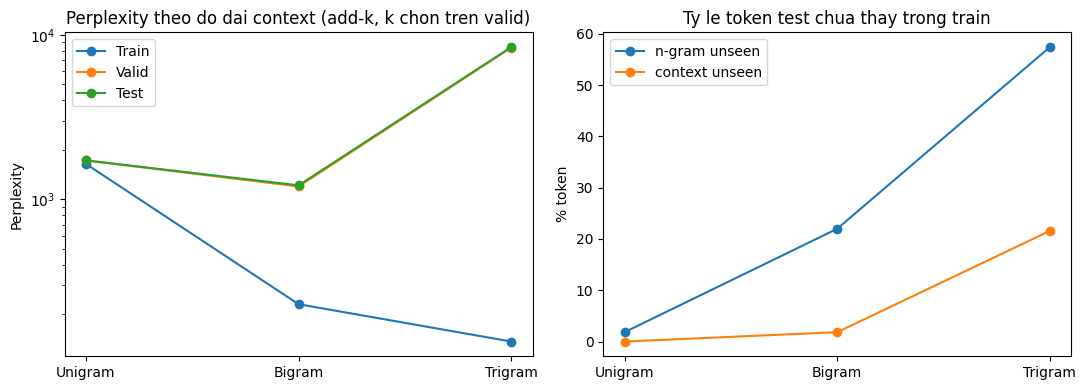

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = [NAMES[n] for n in (1, 2, 3)]
for split in ("Train", "Valid", "Test"):
    axes[0].plot(order, addk_df[f"{split} PPL"], marker="o", label=split)
axes[0].set_yscale("log")
axes[0].set_title("Perplexity theo do dai context (add-k, k chon tren valid)")
axes[0].set_ylabel("Perplexity")
axes[0].legend()

axes[1].plot(order, stats_df["Unseen tokens % (test)"], marker="o", label="n-gram unseen")
axes[1].plot(order, stats_df["Unseen context tokens % (test)"], marker="o", label="context unseen")
axes[1].set_title("Ty le token test chua thay trong train")
axes[1].set_ylabel("% token")
axes[1].legend()
plt.tight_layout()
plt.show()

## Lưu kết quả vào `results.csv`

In [ ]:
import csv
import os

RESULTS_PATH = os.path.join(os.path.dirname(CORPUS_PATH), "results.csv")

with open(RESULTS_PATH, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([])
    writer.writerow(["experiment", "model", "train_unique_ngrams", "test_unique_ngrams", "unseen_types_test",
                     "unseen_types_pct_test", "unseen_tokens_pct_valid", "unseen_tokens_pct_test",
                     "unseen_context_tokens_pct_test"])
    for _, r in stats_df.iterrows():
        writer.writerow(["ctxlen_unseen", r["Model"], r["Train unique n-grams"], r["Test unique n-grams"],
                         r["Unseen types (test)"], round(r["Unseen types % (test)"], 4),
                         round(r["Unseen tokens % (valid)"], 4), round(r["Unseen tokens % (test)"], 4),
                         round(r["Unseen context tokens % (test)"], 4)])

    writer.writerow([])
    writer.writerow(["experiment", "model", "train_ppl", "valid_ppl", "test_ppl"])
    for _, r in ppl_df.iterrows():
        writer.writerow(["ctxlen_ppl", r["Model"], r["Train PPL"], r["Valid PPL"], r["Test PPL"]])
    for _, r in addk_df.iterrows():
        writer.writerow(["ctxlen_ppl", f"{r['Model']} add-k (k={r['best k']})",
                         r["Train PPL"], r["Valid PPL"], r["Test PPL"]])

print("Da luu:", RESULTS_PATH)

Da luu: /content/drive/MyDrive/NLP/lab02/results.csv
